In [13]:
import pandas as pd
import numpy as np
import os
import cv2
from pathlib import Path

def get_video_stats(dog_id, base_video_dir):
    """Uses OpenCV to calculate average resolution and duration of a dog's videos."""
    dog_dir = Path(base_video_dir) / str(dog_id)
    widths = []
    heights = []
    durations = []
    
    if dog_dir.exists():
        video_files = list(dog_dir.glob("*.mp4")) + list(dog_dir.glob("*.avi")) + list(dog_dir.glob("*.mov"))
        for vid_path in video_files:
            cap = cv2.VideoCapture(str(vid_path))
            if cap.isOpened():
                w = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
                h = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
                fps = cap.get(cv2.CAP_PROP_FPS)
                frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
                
                if w > 0 and h > 0:
                    widths.append(w)
                    heights.append(h)
                if fps > 0 and frames > 0:
                    durations.append(frames / fps)
            cap.release()
            
    return pd.Series({
        'Avg_Width': round(np.mean(widths)) if widths else 0,
        'Avg_Height': round(np.mean(heights)) if heights else 0,
        'Avg_Duration_Sec': round(np.mean(durations), 2) if durations else 0.0
    })

def get_splits_statistics(splits_path):
    """Parses splits.csv to count Total, Query, and Gallery videos per dog for the closed set."""
    print(f"Loading splits metadata from {splits_path}...")
    df_splits = pd.read_csv(splits_path)
    
    stats = df_splits.groupby('DOG_ID').agg(
        Total_Vids=('VIDEO_ID', 'count'),
        Query_Vids=('SPLIT_CLOSED_SET', lambda x: (x == 'query').sum()),
        Gallery_Vids=('SPLIT_CLOSED_SET', lambda x: (x == 'gallery').sum())
    ).reset_index()
    
    return stats

def get_ap_per_dog(csv_path):
    """Calculates the Average Precision (AP) for each query in the distance matrix."""
    try:
        df = pd.read_csv(csv_path, index_col=0)
        
        query_dog_ids = [str(idx).split('_')[0] for idx in df.index]
        gallery_dog_ids = np.array([str(col).split('_')[0] for col in df.columns])
        
        results = []
        for i, query_id in enumerate(df.index):
            actual_id = query_dog_ids[i]
            
            distances = df.iloc[i].values
            sorted_indices = np.argsort(distances)
            sorted_gallery_ids = gallery_dog_ids[sorted_indices]
            
            matches = (sorted_gallery_ids == actual_id)
            num_positives = matches.sum()
            
            if num_positives == 0:
                ap = 0.0
            else:
                cumsum = np.cumsum(matches)
                ranks = np.arange(1, len(matches) + 1)
                precisions = cumsum / ranks
                ap = np.sum(precisions * matches) / num_positives
                
            results.append({
                'DOG_ID': actual_id,
                'AP': ap
            })
            
        return pd.DataFrame(results)
    except Exception as e:
        print(f"Skipping {csv_path} due to error: {e}")
        return pd.DataFrame()

def analyze_closed_models(results_dir, splits_path, video_dir):
    # 1. Get Video Statistics from splits.csv
    splits_stats = get_splits_statistics(splits_path)
    
    # 2. Process all Distance Matrices
    closed_data = []
    csv_files = list(Path(results_dir).rglob('*.csv'))
    print(f"Found {len(csv_files)} result files. Processing distance matrices...")

    for file in csv_files:
        if 'closed' in str(file).lower():
            df_res = get_ap_per_dog(file)
            if not df_res.empty:
                closed_data.append(df_res)

    if not closed_data:
        print("No closed world distance matrices found.")
        return pd.DataFrame()

    # Combine AP results from all CSVs
    final_df = pd.concat(closed_data, ignore_index=True)
    
    # Calculate average mAP per DOG_ID
    dog_perf = final_df.groupby('DOG_ID')['AP'].mean().reset_index()
    dog_perf = dog_perf.rename(columns={'AP': 'mAP'})
    
    # 3. Merge mAP with Splits Metadata
    merged_df = pd.merge(dog_perf, splits_stats, on='DOG_ID', how='inner')
    
    # 4. Extract physical video metadata (Resolution and Duration)
    print("Extracting physical video metadata (resolution, duration) via OpenCV...")
    # Apply the OpenCV function to each unique DOG_ID
    video_metadata = merged_df['DOG_ID'].apply(lambda x: get_video_stats(x, video_dir))
    
    # Concatenate the new columns back to the main dataframe
    merged_df = pd.concat([merged_df, video_metadata], axis=1)
    
    # Format Resolution as a clean string for readability
    merged_df['Avg_Resolution'] = merged_df.apply(
        lambda row: f"{int(row['Avg_Width'])}x{int(row['Avg_Height'])}", axis=1
    )
    
    # Sort by mAP descending
    merged_df = merged_df.sort_values(by='mAP', ascending=False)
    
    # Reorder columns to make them neat
    columns_order = [
        'DOG_ID', 'mAP', 'Total_Vids', 'Query_Vids', 'Gallery_Vids', 
        'Avg_Resolution', 'Avg_Width', 'Avg_Height', 'Avg_Duration_Sec'
    ]
    merged_df = merged_df[columns_order]
    
    return merged_df

# --- Execution ---
# Paths
RESULTS_DIR = 'csvs'
SPLITS_FILE = r"C:\Users\marko\Desktop\DogReID-1553\splits.csv"
VIDEOS_DIR = r"C:\Users\marko\Desktop\DogReID-1553\Videos"


closed_results = analyze_closed_models(RESULTS_DIR, SPLITS_FILE, VIDEOS_DIR)

Loading splits metadata from C:\Users\marko\Desktop\DogReID-1553\splits.csv...
Found 12 result files. Processing distance matrices...
Extracting physical video metadata (resolution, duration) via OpenCV...

================ CLOSED WORLD (mAP & STATS) ================
--- TOP 10 BEST PERFORMING DOGS (HALL OF FAME) ---
                              DOG_ID      mAP  Query_Vids  Gallery_Vids Avg_Resolution  Avg_Duration_Sec
af71282c-873b-4c3c-8398-f5cb22aac102 1.000000           1             1      1080x1920              1.63
2bfe9460-bf97-48e3-b258-4ac5233e3f55 0.979167           4             1      1008x1792             11.81
83bd4a16-7033-49cf-914d-74baf4afdc21 0.972685           2             3      1080x1920             14.01
05468985-0eb6-4493-8cad-970e51ca9128 0.962963           3             2      1728x3072              7.01
a6c4d7b5-08ff-4530-8b51-c1470cbe35ac 0.956944           1             4      1080x1920             11.81
707d71ba-06f4-4566-8232-05bf39cd5047 0.956349      

In [22]:
if not closed_results.empty:
    print("\n================ CLOSED WORLD (mAP & STATS) ================")
    print("--- TOP 10 BEST PERFORMING DOGS (HALL OF FAME) ---")
    # Displaying selected columns for cleaner console output
    print(closed_results[['DOG_ID', 'mAP', 'Query_Vids', 'Gallery_Vids', 'Avg_Resolution', 'Avg_Duration_Sec']].head(10).to_string(index=False))
    
    print("\n--- TOP 10 WORST PERFORMING DOGS (HALL OF SHAME) ---")
    print(closed_results[['DOG_ID', 'mAP', 'Query_Vids', 'Gallery_Vids', 'Avg_Resolution', 'Avg_Duration_Sec']].tail(10).to_string(index=False))
    
    # Save the combined DataFrame to CSV
    save_path = 'dog_performance_closed_world_mAP_splits_metadata.csv'
    closed_results.to_csv(save_path, index=False)


================ CLOSED WORLD (mAP & STATS) ================
--- TOP 10 BEST PERFORMING DOGS (HALL OF FAME) ---
                              DOG_ID      mAP  Query_Vids  Gallery_Vids Avg_Resolution  Avg_Duration_Sec
af71282c-873b-4c3c-8398-f5cb22aac102 1.000000           1             1      1080x1920              1.63
2bfe9460-bf97-48e3-b258-4ac5233e3f55 0.979167           4             1      1008x1792             11.81
83bd4a16-7033-49cf-914d-74baf4afdc21 0.972685           2             3      1080x1920             14.01
05468985-0eb6-4493-8cad-970e51ca9128 0.962963           3             2      1728x3072              7.01
a6c4d7b5-08ff-4530-8b51-c1470cbe35ac 0.956944           1             4      1080x1920             11.81
707d71ba-06f4-4566-8232-05bf39cd5047 0.956349           2             3      1080x1920             10.43
72b8f97d-3149-48a4-819a-05ba5ad7952e 0.948512           5             4      1492x2151             12.15
e25b07af-c083-4a8f-a730-2fa62a0ce01e 0.944444  

Generating Hall of Fame (Best 10)...
Saved Top 10 Best Performing Dogs plot to hall_of_fame.png


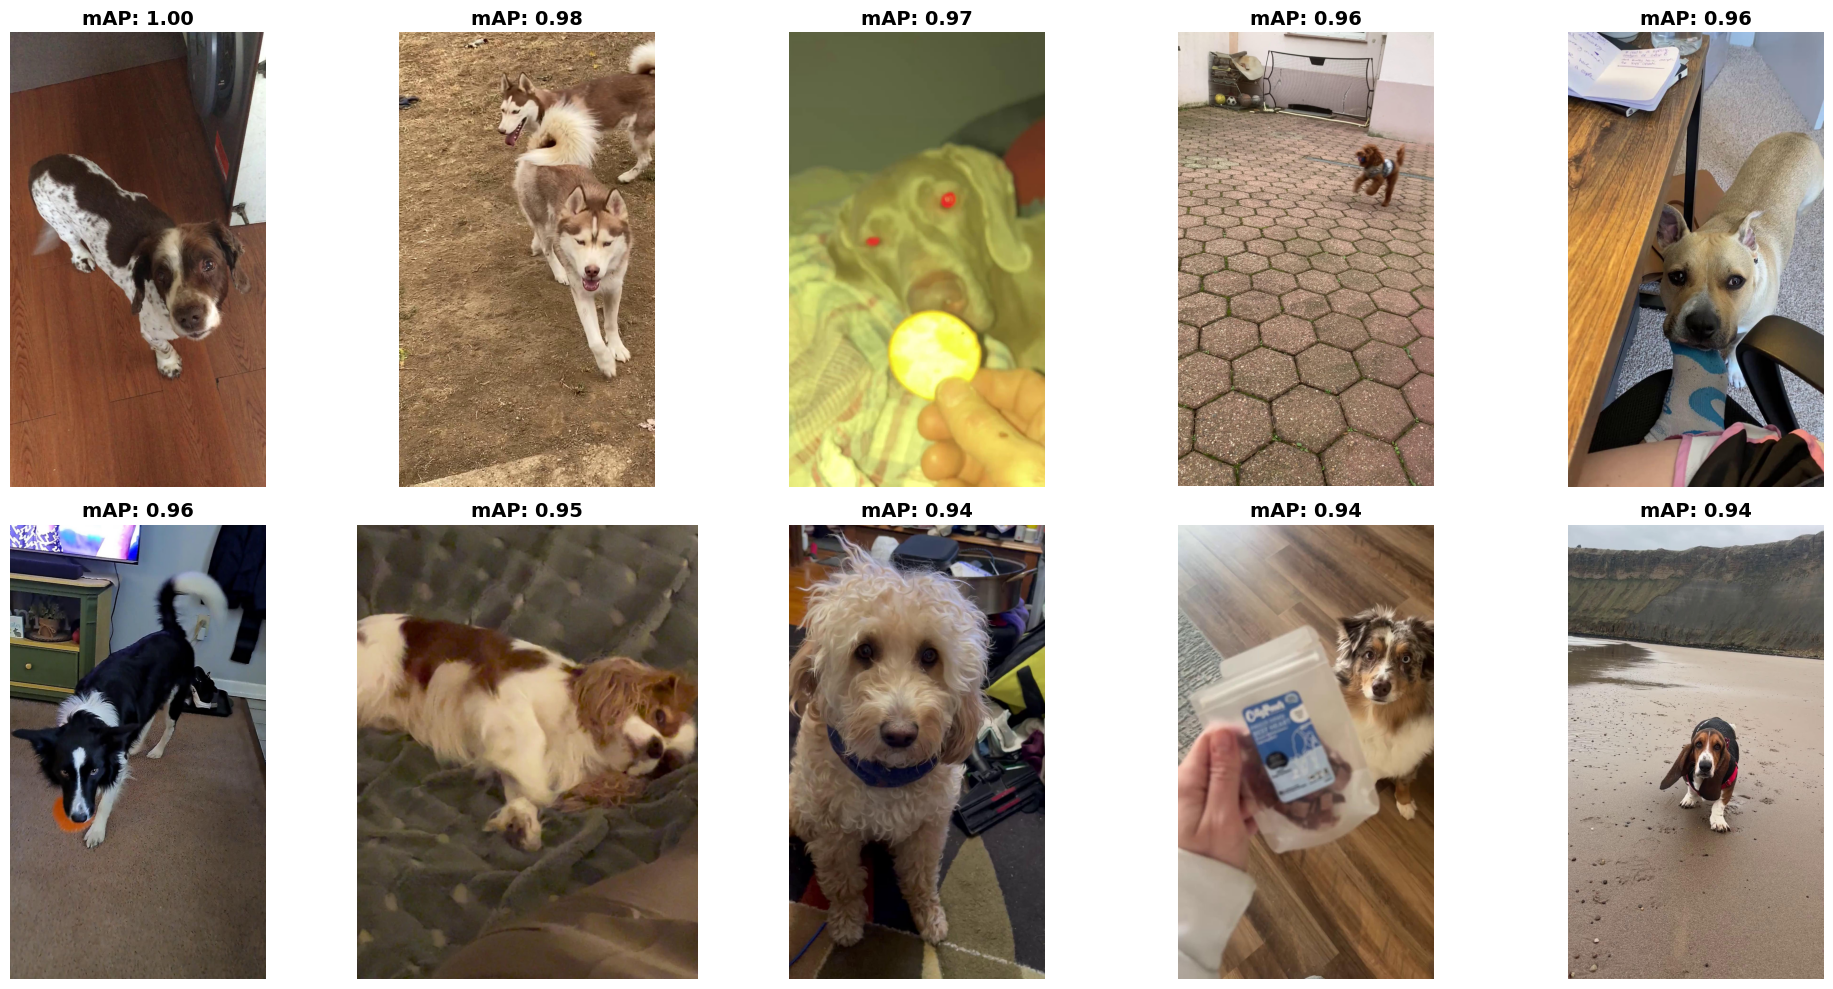

Generating Hall of Shame (Worst 10)...
Saved Bottom 10 Worst Performing Dogs plot to hall_of_shame.png


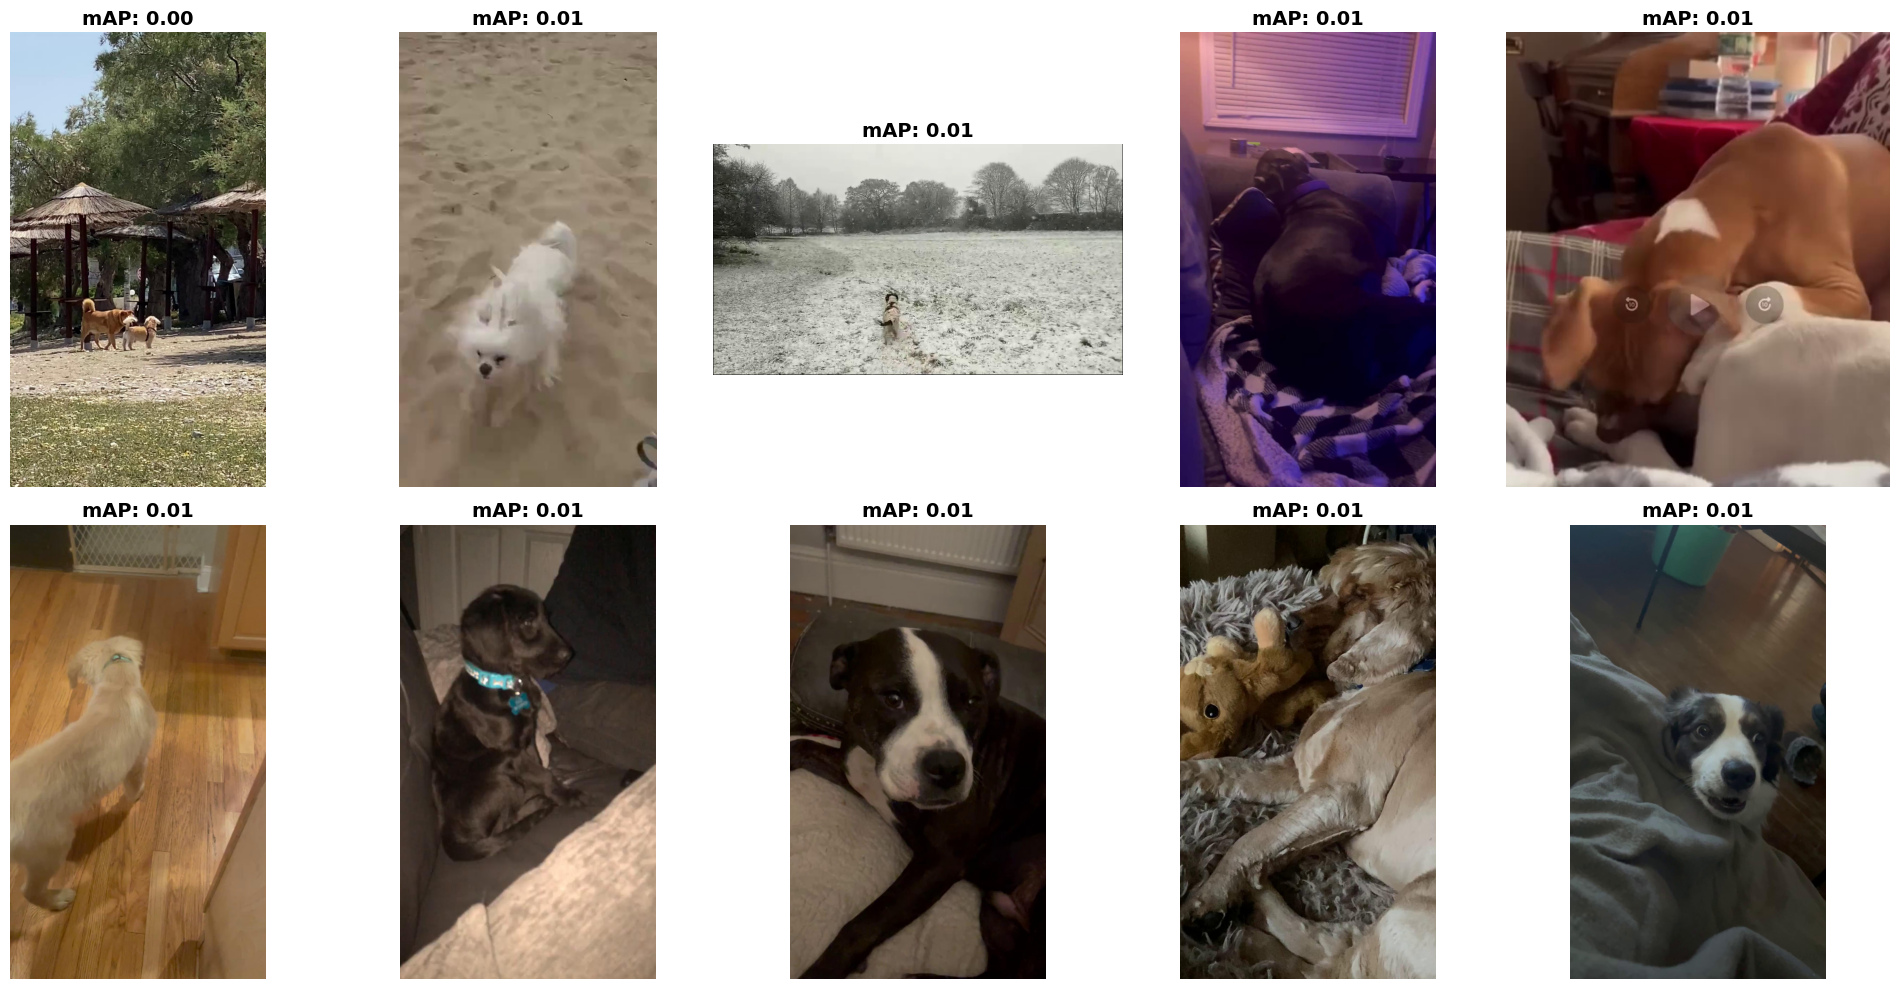

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path

def plot_dog_grid(dog_ids, scores, title, save_name):
    """Plots a 2x5 grid of dog images."""
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.flatten()
    
    base_image_path = Path(r"C:\Users\marko\Desktop\DogReID-1553\Images")

    for i, (dog_id, score) in enumerate(zip(dog_ids, scores)):
        ax = axes[i]
        
        # Path: Images/DOG_ID/
        dog_dir = base_image_path / dog_id
        
        # Find the first image in the directory
        img_path = None
        if dog_dir.exists():
            images = list(dog_dir.glob("*.jpg")) + list(dog_dir.glob("*.png"))
            if images:
                img_path = images[0]

        if img_path:
            img = mpimg.imread(str(img_path))
            ax.imshow(img)
        else:
            # Placeholder if image is missing
            ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center')
            ax.set_facecolor('#f0f0f0')

        ax.set_title(f"mAP: {score:.2f}", fontsize=14, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    print(f"Saved {title} plot to {save_name}")
    plt.show()

# --- Execution ---

# 1. Get IDs and Scores for Best 10
top_10 = closed_results.head(10)
top_ids = top_10['DOG_ID'].tolist()
top_scores = top_10['mAP'].tolist()

# 2. Get IDs and Scores for Worst 10
worst_10 = closed_results.tail(10).iloc[::-1] # Reverse so the absolute worst is first
worst_ids = worst_10['DOG_ID'].tolist()
worst_scores = worst_10['mAP'].tolist()

# 3. Generate the Plots
print("Generating Hall of Fame (Best 10)...")
plot_dog_grid(top_ids, top_scores, "Top 10 Best Performing Dogs", "hall_of_fame.png")

print("Generating Hall of Shame (Worst 10)...")
plot_dog_grid(worst_ids, worst_scores, "Bottom 10 Worst Performing Dogs", "hall_of_shame.png")

In [ ]:
import tempfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from evaluation_utils import bootstrap_from_csv

# --- Define models and paths ---
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_closed/closed_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_closed_image/closed_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_closed/closed_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_closed_image/closed_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_closed/closed_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_closed_image/closed_dist_matrix.csv"
}

def run_gallery_per_id_sensitivity(models_dict, scales=[0.2, 0.5, 1.0]):
    sensitivity_results = {}

    for name, path in models_dict.items():
        print(f"\n{'='*40}\nProcessing {name}\n{'='*40}")
        
        df_full = pd.read_csv(path)
        get_id = lambda x: str(x).rsplit('_', 1)[0]

        query_labels = np.array([get_id(i) for i in df_full["queryId"].values])
        gallery_ids = df_full.columns[1:]
        gallery_labels = np.array([get_id(i) for i in gallery_ids])

        unique_ids = np.unique(gallery_labels)

        # Build mapping: identity -> column indices
        id_to_indices = {
            uid: np.where(gallery_labels == uid)[0]
            for uid in unique_ids
        }

        np.random.seed(42)
        model_stats = []

        for s in tqdm(scales, desc="Scaling images per identity", leave=False):
            selected_indices = []

            for uid, idxs in id_to_indices.items():
                n_total = len(idxs)
                n_keep = max(1, int(np.ceil(n_total * s)))  # ensure at least 1

                chosen = np.random.choice(idxs, size=n_keep, replace=False)
                selected_indices.extend(chosen)

            selected_indices = np.array(sorted(selected_indices))

            selected_cols = [df_full.columns[0]] + list(gallery_ids[selected_indices])
            tmp_df = df_full[selected_cols]

            with tempfile.TemporaryDirectory() as tmp_dir:
                tmp_csv = os.path.join(tmp_dir, "sensitivity_step.csv")
                tmp_df.to_csv(tmp_csv, index=False)

                res = bootstrap_from_csv(tmp_csv, m=1, mode="closed")
                target_metrics = res.get("full_set", res)

                model_stats.append({
                    "scale": s * 100,
                    "mAP": target_metrics["mAP"],
                    "Rank1": target_metrics["cmc"][0],
                    "Rank5": target_metrics["cmc"][4] if len(target_metrics["cmc"]) > 4 else np.nan
                })

        sensitivity_results[name] = pd.DataFrame(model_stats)

    return sensitivity_results


# --- Run ---
sensitivity_data = run_gallery_per_id_sensitivity(
    models_to_test,
    scales=[0.1, 0.2, 0.3,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)


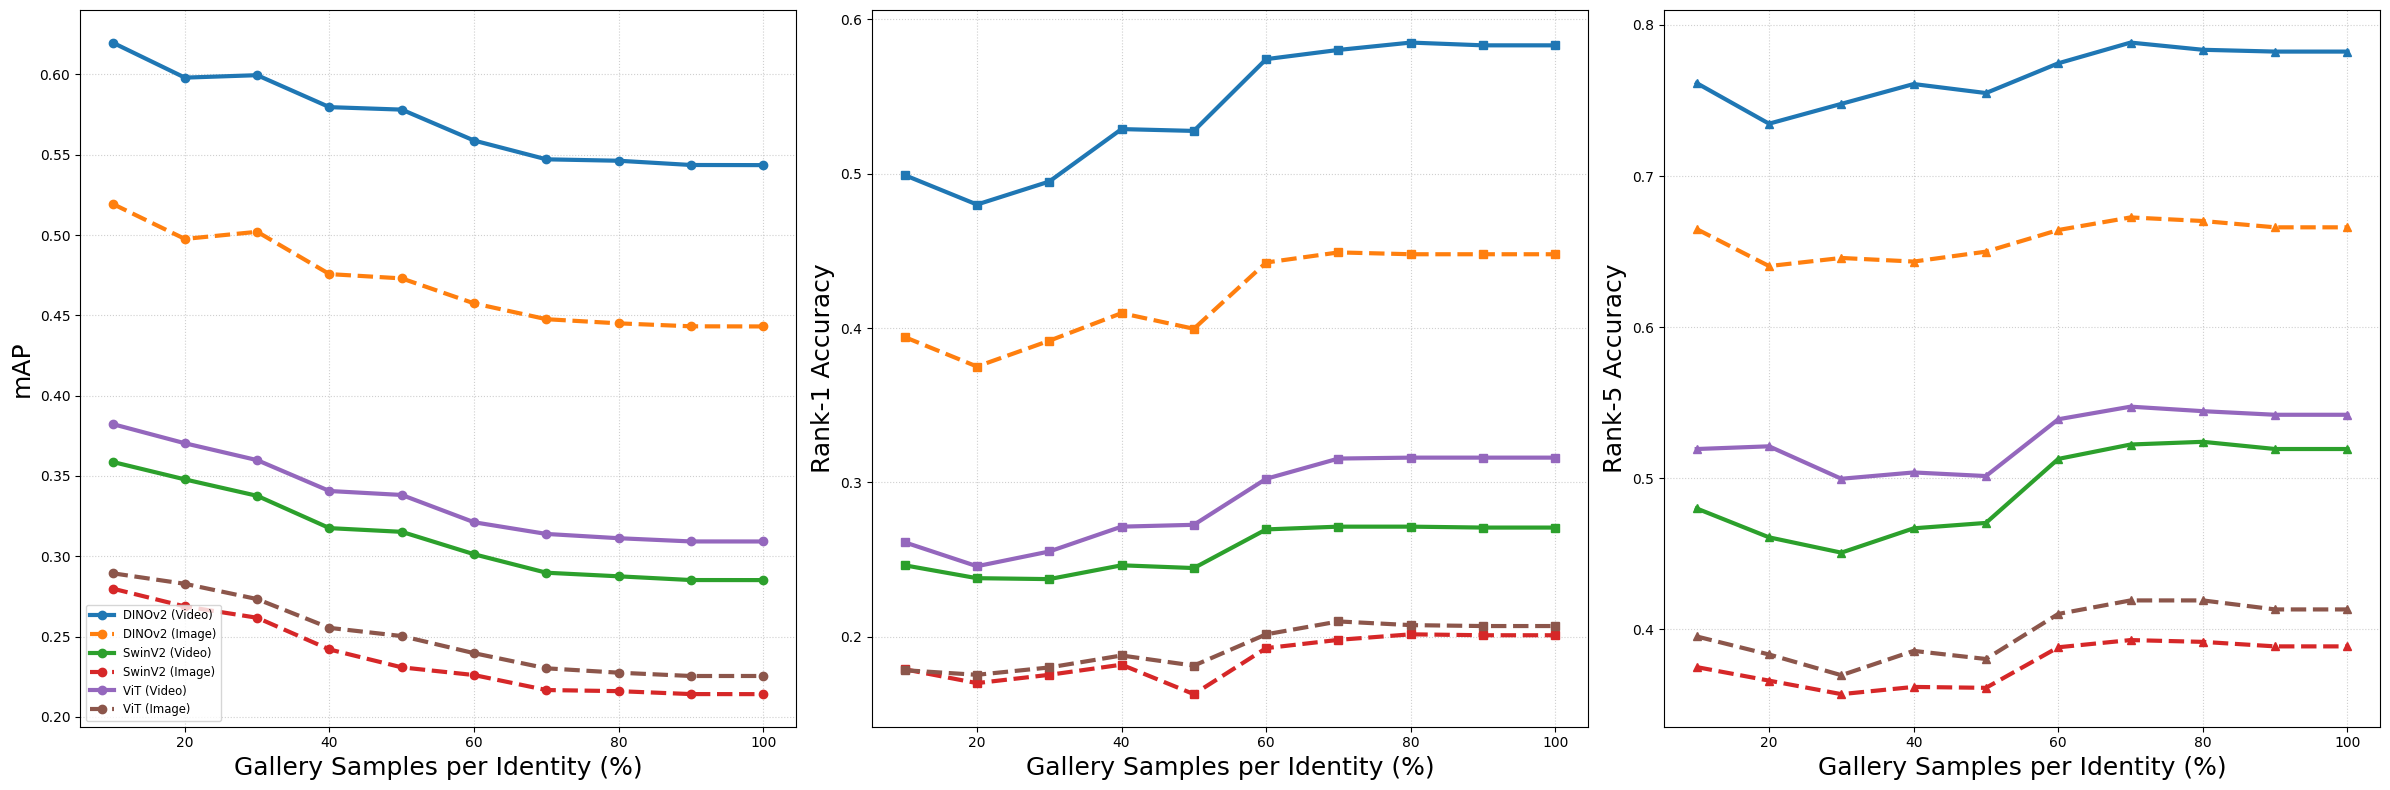

In [20]:
# ---------------------------------------------------------------------------
# --- Plotting Results ---
# ---------------------------------------------------------------------------
def plot_sensitivity_final(results):
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    fs = 18

    ax1, ax2, ax3 = axes

    for name, df in results.items():
        ls = '-' if "(Video)" in name else '--'

        ax1.plot(df['scale'], df['mAP'], marker='o', label=name, linestyle=ls, linewidth=3)
        ax2.plot(df['scale'], df['Rank1'], marker='s', label=name, linestyle=ls, linewidth=3)
        ax3.plot(df['scale'], df['Rank5'], marker='^', label=name, linestyle=ls, linewidth=3)


    # --- Labels ---
    for ax in axes:
        ax.set_xlabel("Gallery Samples per Identity (%)", fontsize=fs)
        ax.grid(True, linestyle=':', alpha=0.6)

    ax1.set_ylabel("mAP", fontsize=fs)
    ax2.set_ylabel("Rank-1 Accuracy", fontsize=fs)
    ax3.set_ylabel("Rank-5 Accuracy", fontsize=fs)

    # --- Legend (only once to avoid clutter) ---
    ax1.legend(fontsize='small', loc='lower left')

    plt.tight_layout()
    plt.show()


plot_sensitivity_final(sensitivity_data)